# 🧠 Project: 基于 EEGNet + Transformer 的脑电情绪识别模型

## 1. 项目简介
本项目旨在构建一个能够处理多通道 EEG（脑电图）信号的深度学习模型。我们将通过以下步骤实现从数据到结果的完整链路：
1. **信号预处理**：带通滤波去除噪声，Z-score 标准化统一数据分布。
2. **数据加载**：使用滑动窗口技术增强数据，构建 PyTorch 数据集。
3. **模型构建**：设计 `EEGBiFormer` 模型，结合 **CNN**（提取局部波形特征）和 **Transformer**（捕捉长时序依赖）。
4. **模型训练**：使用加权 Loss 处理样本不平衡，配合早停机制（Early Stopping）防止过拟合。
5. **结果评估**：绘制 Loss/Accuracy 曲线与混淆矩阵。

首先，我们需要导入项目所需的 Python 库。

In [1]:
# --- 导入必要的库 ---
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay # 用于评估模型性能
import pandas as pd
import numpy as np
import os
from tqdm import tqdm # 进度条工具
from scipy.signal import butter, filtfilt # 信号处理工具
import matplotlib.pyplot as plt # 绘图工具
from torch.optim.lr_scheduler import ReduceLROnPlateau # 学习率调整策略

# 检查当前设备（优先使用 GPU）
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"当前运行设备: {device}")

当前运行设备: cuda


## 2. 信号预处理：带通滤波器 (Bandpass Filter)

原始的脑电信号通常包含很多噪声（如由眨眼引起的低频漂移，或由肌肉活动引起的高频噪声）。为了提取有效的情绪特征，我们需要保留特定频段的信号。

我们根据**奈奎斯特采样定理**设计一个巴特沃斯（Butterworth）带通滤波器：
* **低截止频率 (0.5 Hz)**：去除直流偏移和极低频漂移。
* **高截止频率 (40 Hz)**：保留 $\delta, \theta, \alpha, \beta, \gamma$ 波段，去除高频肌电干扰。

In [2]:
# --- 带通滤波器函数 ---
# --- Bandpass Filter Function ---

def bandpass_filter(data, sampling_rate, lowcut, highcut): # 定义带通滤波器函数 / Define the bandpass filter function.
    """
    对输入数据应用一个4阶巴特沃斯带通滤波器。
    Applies a 4th-order Butterworth bandpass filter to the input data.

    参数 (Parameters):
    - data (np.ndarray): 输入的信号数据，形状为 (时间点数, 通道数)。/ Input signal data, with shape (number of time points, number of channels).
    - sampling_rate (int): 信号的采样率 (Hz)。/ The sampling rate of the signal (Hz).
    - lowcut (float): 低频截止频率 (Hz)。低于此频率的信号将被滤除。/ Low-frequency cutoff (Hz). Signals below this frequency will be filtered out.
    - highcut (float): 高频截止频率 (Hz)。高于此频率的信号将被滤除。/ High-frequency cutoff (Hz). Signals above this frequency will be filtered out.

    返回 (Returns):
    - y (np.ndarray): 滤波后的信号数据。/ The filtered signal data.
    """
    # 奈奎斯特频率是采样率的一半，是数字信号能有效表示的最高频率
    # The Nyquist frequency is half the sampling rate, representing the highest frequency a digital signal can effectively represent.
    nyq = 0.5 * sampling_rate
    # 将实际的截止频率转换为相对于奈奎斯特频率的归一化频率
    # Convert the actual cutoff frequencies to normalized frequencies relative to the Nyquist frequency.
    low = lowcut / nyq
    high = highcut / nyq
    
    # 使用 butter 函数设计一个4阶(order=4)的巴特沃斯滤波器
    # Design a 4th-order (order=4) Butterworth filter using the butter function.
    # 返回滤波器的分子(b)和分母(a)系数
    # It returns the numerator (b) and denominator (a) coefficients of the filter.
    b, a = butter(4, [low, high], btype='band')
    
    # 使用 filtfilt 函数对数据进行零相位滤波
    # Apply a zero-phase filter to the data using the filtfilt function.
    # 'filtfilt' 会向前和向后各应用一次滤波器，从而消除相位延迟
    # 'filtfilt' applies the filter once forward and once backward, thereby canceling out phase delay.
    # axis=0 表示沿着时间轴（第一个维度）进行滤波
    # axis=0 indicates that filtering is performed along the time axis (the first dimension).
    y = filtfilt(b, a, data, axis=0)
    
    return y # 返回滤波后的数据 / Return the filtered data.

print("Function 'bandpass_filter' has been successfully defined!") # 打印一条消息，确认函数已成功定义 / Print a message to confirm the function has been successfully defined.

Function 'bandpass_filter' has been successfully defined!


## 3. 构建数据集类 (EEGDataset)

在深度学习中，我们需要继承 `torch.utils.data.Dataset` 来定义数据的加载方式。这个类主要负责：
1.  **读取 CSV**：从文件夹中读取原始数据。
2.  **预处理**：调用上面的滤波函数，并进行 **Z-score 标准化**（减均值，除方差）。
3.  **滑动窗口 (Sliding Window)**：这是数据增强的关键。我们将长段的脑电信号切分成多个小的、重叠的片段（Window），增加训练样本数量。

In [3]:
class EEGDataset(Dataset): # 定义 EEGDataset 类，它继承自 PyTorch 的 Dataset 类 
    # Define the EEGDataset class, which inherits from PyTorch's Dataset class.
    """
    自定义的PyTorch数据集类，用于加载和预处理EEG数据。
    Custom PyTorch Dataset class for loading and preprocessing EEG data.
    """
    # __init__ 是类的构造函数，在创建类的实例时被调用
    # __init__ is the class constructor, called when an instance of the class is created.
    def __init__(self, root_folder, window_size=404, stride=202, sampling_rate=202):
        # 初始化用于存储处理后数据和标签的列表
        # Initialize two empty lists to store all processed data windows and their corresponding labels.
        self.data, self.labels = [], []
        # 获取根目录下所有子文件夹（即类别名称），并排序以确保每次运行的顺序一致
        # Get all subdirectory names (i.e., class names) under the root folder and sort them to ensure consistent order.
        self.classes = sorted([d for d in os.listdir(root_folder) if os.path.isdir(os.path.join(root_folder, d))])
        # 使用 scikit-learn 的 LabelEncoder 将文本类别名称（如 "focus", "rest"）转换为数字（如 0, 1）
        # Create and fit a LabelEncoder from scikit-learn to convert string class names (e.g., "focus", "rest") into integers (e.g., 0, 1).
        self.label_encoder = LabelEncoder().fit(self.classes)
        # 存储脑电信号的采样率
        # Store the sampling rate of the EEG signal as a class attribute.
        self.sampling_rate = sampling_rate

        # 遍历每一个类别文件夹
        # Loop through each class folder.
        # enumerate 同时提供索引 (label_idx) 和值 (label)
        # enumerate provides both the index (label_idx) and the value (label).
        for label_idx, label in enumerate(self.classes):
            # 构建当前类别文件夹的完整路径
            # Construct the full path to the current class folder.
            class_path = os.path.join(root_folder, label)
            # 遍历当前类别文件夹中的所有文件
            # Loop through all files in the current class folder.
            for file in os.listdir(class_path):
                # 检查文件是否是 .csv 文件
                # Check if the file is a .csv file.
                if file.endswith('.csv'):
                    # 构建当前 CSV 文件的完整路径
                    # Construct the full path to the current CSV file.
                    file_path = os.path.join(class_path, file)
                    # 使用 try-except 块来捕获和处理可能的文件读取或处理错误
                    # Use a try-except block to catch and handle potential file reading or processing errors.
                    try:
                        # --- 数据处理流程 ---
                        # --- Data Processing Pipeline ---
                        
                        # 步骤 1: 加载数据 (只取16个通道)
                        # Step 1: Load data (taking only 16 channels).
                        full_data = pd.read_csv(file_path, skiprows=1, usecols=range(1, 17)).values.astype(np.float64)

                        # 步骤 2: 滤波
                        # Step 2: Filtering.
                        full_data = bandpass_filter(full_data, sampling_rate=self.sampling_rate, lowcut=4, highcut=40)

                        # 步骤 3: Z-score 标准化 (带安全检查)
                        # Step 3: Z-score Standardization (with a safety check).
                        for i in range(full_data.shape[1]): # 遍历数据的每一个通道（列）进行标准化 / Loop through each channel (column) of the data for standardization.
                            mean = np.mean(full_data[:, i]) # 计算当前通道的平均值 / Calculate the mean of the current channel.
                            std = np.std(full_data[:, i])   # 计算当前通道的标准差 / Calculate the standard deviation of the current channel.
                            if std > 1e-8: # 防止除以零 / Prevent division by zero.
                                full_data[:, i] = (full_data[:, i] - mean) / std # 应用 Z-score 标准化公式 / Apply the Z-score standardization formula.
                            else: # 如果标准差为零，则将该通道所有值设为0 / If the standard deviation is zero, set all values in this channel to 0.
                                full_data[:, i] = 0.0

                        # 步骤 4: 裁剪 (在窗口化之前)
                        # Step 4: Clipping (before windowing).
                        np.clip(full_data, -20.0, 20.0, out=full_data) # 将所有数据点的值限制在 -20 到 20 之间，以去除极端异常值 
                        # Clip all data point values between -20 and 20 to remove extreme outliers.
                        
                        # 步骤 5: 滑动窗口
                        # Step 5: Sliding Window.
                        start = 0 # 初始化滑动窗口的起始位置 / Initialize the starting position of the sliding window.
                        while start + window_size <= len(full_data): # 循环直到窗口的末端超出数据总长度 / Loop until the end of the window exceeds the total data length.
                            window = full_data[start : start + window_size] # 从完整数据中切分出一个窗口 / Slice a window from the full data.
                            self.data.append(window) # 将切分出的窗口添加到数据列表 / Add the sliced window to the data list.
                            self.labels.append(label_idx) # 将对应的数字标签添加到标签列表 / Add the corresponding numerical label to the labels list.
                            start += stride # 将起始位置向前移动一个步长的距离 / Move the starting position forward by one stride.
                            
                    except Exception as e: # 如果 try 块中发生任何错误，则捕获它 / If any error occurs in the try block, catch it.
                        print(f"!!! 处理文件 {file_path} 时出错: {e}") # 打印错误信息，方便调试 / Print the error message for debugging.

        # --- 最终转换和清理 ---
        # --- Final Conversion and Cleanup ---
        self.data = np.array(self.data, dtype=np.float32) # 将存储窗口的列表转换为一个大的 NumPy 数组，并指定数据类型为 float32 / Convert the list of windows into a large NumPy array with data type float32.
        self.labels = np.array(self.labels, dtype=np.int64) # 将标签列表也转换为 NumPy 数组，并指定数据类型为 int64 / Convert the labels list into a NumPy array as well, with data type int64.

        if np.isnan(self.data).any() or np.isinf(self.data).any(): # 检查处理后的数据中是否包含任何 NaN (非数字) 或 Inf (无穷大) 的值 / Check if the processed data contains any NaN (Not a Number) or Inf (Infinity) values.
            print("\n!!! 警告: 处理后发现 NaN 或 Inf 值，正在清理。") # 如果发现坏值，打印一条警告信息 / If bad values are found, print a warning message.
            self.data = np.nan_to_num(self.data, nan=0.0, posinf=0.0, neginf=0.0) # 将所有 NaN 和 Inf 值替换为 0.0，确保数据纯净 / Replace all NaN and Inf values with 0.0 to ensure data purity.
        
    def __len__(self): # 定义 __len__ 方法，它返回数据集中的样本总数 / Define the __len__ method, which returns the total number of samples in the dataset.
        # 返回数据集中样本的总数
        # Return the total number of samples in the dataset.
        return len(self.data)

    def __getitem__(self, idx): # 定义 __getitem__ 方法，根据索引获取单个数据样本 / Define the __getitem__ method to retrieve a single data sample by its index.
        # 根据索引 idx，返回对应的数据和标签
        # Based on the index idx, return the corresponding data and label.
        # 将 NumPy 数组转换为 PyTorch 的 Tensor
        # Convert the NumPy arrays to PyTorch Tensors.
        return torch.from_numpy(self.data[idx]), torch.from_numpy(np.array(self.labels[idx]))

print("EEGDataset has been successfully defined!") # 打印一条消息，确认类已成功定义 / Print a message to confirm the class has been successfully defined.

EEGDataset has been successfully defined!


Loading data from './dataset/train'...

Data loading and preprocessing complete!
--- Dataset Summary ---
Total samples generated (via sliding window): 3440
Class mapping: {np.str_('Alert'): np.int64(0), np.str_('Nervous'): np.int64(1), np.str_('Relaxed'): np.int64(2)}

--- First Sample Details ---
Data type: torch.float32
Data shape (Time Points, Channels): torch.Size([404, 16])
Label: 0 (Corresponding class: 'Alert')


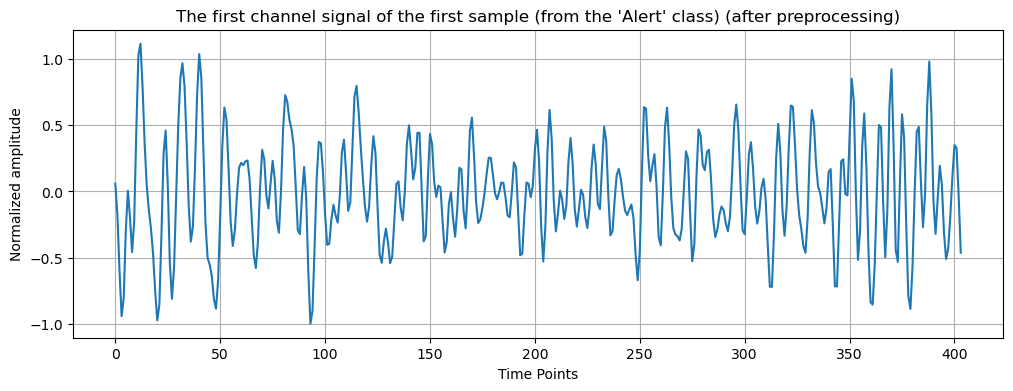

In [4]:
# --- 实例化并检查EEGDataset ---
# --- Instantiate and Inspect EEGDataset ---

# 定义你的实际训练数据文件夹路径
# Define the path to your actual training data folder.
train_data_path = "./dataset/train"

# 检查路径是否存在，提供更友好的提示
# Check if the path exists to provide a more user-friendly prompt.
if not os.path.isdir(train_data_path):
    # 如果路径不存在，打印错误信息 / If the path does not exist, print an error message.
    print(f"Error: Dataset path not found at '{train_data_path}'") # 中文注释: 打印错误信息
    # 打印提示信息，指导用户如何解决问题 / Print a hint to guide the user on how to solve the issue.
    print("Please ensure your notebook file and the 'dataset' folder are in the same directory.") # 中文注释: 打印提示信息
else:
    # 如果路径存在，打印加载信息 / If the path exists, print a loading message.
    print(f"Loading data from '{train_data_path}'...") # 中文注释: 打印加载信息
    # 使用你的实际训练数据文件夹来实例化 EEGDataset
    # Instantiate EEGDataset using your actual training data folder.
    # 窗口大小404点（约2秒），步长202点（约1秒）
    # Window size of 404 points (approx. 2 seconds), stride of 202 points (approx. 1 second).
    train_dataset = EEGDataset(root_folder=train_data_path, window_size=404, stride=202)

    # --- 打印数据集信息 ---
    # --- Print Dataset Information ---
    if len(train_dataset) > 0: # 检查数据集是否成功生成了样本 / Check if the dataset has successfully generated any samples.
        print("\nData loading and preprocessing complete!") # 中文注释: 打印成功消息
        print("--- Dataset Summary ---") # 中文注释: 打印摘要标题
        print(f"Total samples generated (via sliding window): {len(train_dataset)}") # 中文注释: 打印通过滑动窗口生成的总样本数
        
        # 检查类别和它们的编码
        # Check the classes and their encodings.
        class_mapping = dict(zip(train_dataset.label_encoder.classes_, train_dataset.label_encoder.transform(train_dataset.label_encoder.classes_)))
        # 打印类别名称到数字标签的映射关系 / Print the mapping from class names to numerical labels.
        print(f"Class mapping: {class_mapping}") # 中文注释: 打印类别映射

        # 获取第一个样本并检查其属性
        # Get the first sample and inspect its properties.
        first_sample_data, first_sample_label = train_dataset[0]
        print(f"\n--- First Sample Details ---") # 中文注释: 打印样本详情标题
        print(f"Data type: {first_sample_data.dtype}") # 中文注释: 打印样本数据的类型
        print(f"Data shape (Time Points, Channels): {first_sample_data.shape}") # 中文注释: 打印样本数据的形状
        
        # 获取标签对应的类别名称
        # Get the class name corresponding to the label.
        label_name = train_dataset.label_encoder.inverse_transform([first_sample_label.item()])[0]
        # 打印样本的数字标签和其对应的原始类别名 / Print the sample's numerical label and its corresponding original class name.
        print(f"Label: {first_sample_label.item()} (Corresponding class: '{label_name}')") # 中文注释: 打印标签及其对应的类别名

        # 可视化第一个样本的第一个通道，直观感受数据经过完整预处理后的样子
        # Visualize the first channel of the first sample to intuitively see what the data looks like after the full preprocessing pipeline.
        plt.figure(figsize=(12, 4)) # 创建一个新的图形，并设置其大小 / Create a new figure and set its size.
        plt.plot(first_sample_data[:, 0].numpy()) # 绘制第一个通道的数据 / Plot the data of the first channel.

        # 设置图形的标题（英文） / Set the title of the plot (in English).
        plt.title(f"The first channel signal of the first sample (from the '{label_name}' class) (after preprocessing)")
        # 设置 x 轴的标签 / Set the label for the x-axis.
        plt.xlabel("Time Points")
        # 设置 y 轴的标签 / Set the label for the y-axis.
        plt.ylabel("Normalized amplitude")
        # 设置图形的标题（中文） / Set the title of the plot (in Chinese).
        #plt.title(f"第一个样本 (来自 '{label_name}' 类) 的第一个通道信号 (预处理后)")
        # 设置 x 轴的标签（中文） / Set the label for the x-axis (in Chinese).
        #plt.xlabel("时间点 (Time Points)")
        # 设置 y 轴的标签（中文） / Set the label for the y-axis (in Chinese).
        #plt.ylabel("标准化后的幅值")
        plt.grid(True) # 显示网格线 / Display grid lines.
        plt.show() # 显示图形 / Show the plot.
    else:
        # 如果数据集中没有样本，打印警告信息 / If there are no samples in the dataset, print a warning message.
        print(f"\nWarning: Data loading finished, but no samples were generated from '{train_data_path}'.") # 中文注释: 打印警告信息
        # 打印可能的原因，帮助用户排查问题 / Print possible reasons to help the user troubleshoot.
        print("Please check if your .csv files are empty, correctly formatted, or if the data length is sufficient to create a window.") # 中文注释: 打印可能的原因

## 4. 模型架构：EEGBiFormer

为了从脑电信号中解码情绪，我们设计了一个混合模型：

1.  **CNN (卷积神经网络)**：作为特征提取器。使用 `Conv1d` 在时间轴上滑动，提取局部的波形特征（如特定的波峰波谷模式）。
2.  **Transformer Encoder**：利用**自注意力机制 (Self-Attention)**，捕捉长距离的时间依赖关系。它能理解“现在的波形”与“之前的波形”之间的关联。
3.  **Stable Initialization**：我们使用了 Kaiming 初始化等策略，确保模型在训练初期梯度稳定。

**数据流向：** `(Batch, Time, Channel)` -> `Transpose` -> `CNN` -> `Transpose` -> `Transformer` -> `AvgPool` -> `Linear` -> `Output`

In [5]:
# 导入 PyTorch 核心库
# Import core PyTorch libraries
import torch
# 导入 PyTorch 的神经网络模块，我们用它来构建模型层
# Import PyTorch's neural network module, which we use to build model layers
import torch.nn as nn

# 定义 EEGBiFormer 模型类，它继承自 PyTorch 的 nn.Module
# Define the EEGBiFormer model class, which inherits from nn.Module
class EEGBiFormer(nn.Module):
    """
    自定义的EEG分类模型，结合了CNN和Transformer。
    A custom EEG classification model that combines CNN and Transformer.
    """
    # 定义构造函数，初始化模型的各个层
    # Define the constructor to initialize the model's layers
    def __init__(self, num_classes, in_channels=16, dim=256):
        # 调用父类 nn.Module 的构造函数，这是自定义模块所必需的
        # Call the constructor of the parent class, nn.Module, which is necessary for custom modules
        super().__init__()
        
        # --- 输入数据的批标准化层 ---
        # --- Input Data Batch Normalization Layer ---
        # 对输入的16个通道进行标准化，增强训练稳定性
        # Normalize the 16 input channels to enhance training stability
        self.input_norm = nn.BatchNorm1d(in_channels)
        
        # --- CNN 特征提取器模块 ---
        # --- CNN Feature Extractor Module ---
        # 使用 nn.Sequential 将多个层组合成一个模块
        # Use nn.Sequential to group multiple layers into a single module
        self.feature_extractor = nn.Sequential(
            # 第一个卷积层：输入通道16，输出通道64，卷积核大小9，padding确保输出长度不变，不使用偏置项
            # First convolutional layer: 16 input channels, 64 output channels, kernel size of 9, padding ensures output length is unchanged, no bias term
            nn.Conv1d(in_channels, 64, kernel_size=9, padding=4, bias=False),
            # 对64个通道进行批标准化
            # Batch normalization for the 64 channels
            nn.BatchNorm1d(64),
            # ReLU 激活函数，引入非线性
            # ReLU activation function to introduce non-linearity
            nn.ReLU(),
            # 第二个卷积层：输入通道64，输出通道128
            # Second convolutional layer: 64 input channels, 128 output channels
            nn.Conv1d(64, 128, kernel_size=9, padding=4, bias=False),
            # 对128个通道进行批标准化
            # Batch normalization for the 128 channels
            nn.BatchNorm1d(128),
            # ReLU 激活函数
            # ReLU activation function
            nn.ReLU(),
            # 第三个卷积层：输入通道128，输出通道dim (256)
            # Third convolutional layer: 128 input channels, dim (256) output channels
            nn.Conv1d(128, dim, kernel_size=9, padding=4, bias=False),
            # 对dim(256)个通道进行批标准化
            # Batch normalization for the dim(256) channels
            nn.BatchNorm1d(dim),
            # ReLU 激活函数
            # ReLU activation function
            nn.ReLU()
        )
        
        # --- Transformer 编码器模块 ---
        # --- Transformer Encoder Module ---
        # 定义一个标准的 Transformer 编码器层
        # Define a standard Transformer Encoder Layer
        encoder_layer = nn.TransformerEncoderLayer(
            # 输入特征的维度 (必须与CNN输出维度一致)
            # The dimension of input features (must match the CNN output dimension)
            d_model=dim,
            # 多头注意力机制中的头数
            # The number of heads in the multi-head attention mechanism
            nhead=8,
            # 前馈网络层的隐藏层维度，通常设为 d_model 的4倍
            # The dimension of the hidden layer in the feed-forward network, typically set to 4 times d_model
            dim_feedforward=dim*4,
            # Dropout 比例，防止过拟合
            # Dropout rate to prevent overfitting
            dropout=0.2,
            # 关键参数！确保输入张量的第一个维度是 batch_size
            # Crucial parameter! Ensures the first dimension of the input tensor is the batch_size
            batch_first=True
        )
        # 将多个编码器层堆叠起来（这里我们使用2层）
        # Stack multiple encoder layers together (here we use 2 layers)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=2)
        
        # --- 分类头模块 ---
        # --- Classification Head Module ---
        # 用于将 Transformer 的输出映射到最终的类别得分
        # Used to map the Transformer's output to the final class scores
        self.head = nn.Sequential(
            # 全连接层，从 dim 维降到 dim/2 维
            # Fully connected layer, reducing dimension from dim to dim/2
            nn.Linear(dim, dim//2),
            # ReLU 激活函数
            # ReLU activation function
            nn.ReLU(),
            # Dropout 层，进一步防止过拟合
            # Dropout layer to further prevent overfitting
            nn.Dropout(0.2),
            # 输出层，维度为类别数
            # Output layer, with dimension equal to the number of classes
            nn.Linear(dim//2, num_classes)
        )
        
        # 应用自定义的权重初始化方法，有助于稳定训练
        # Apply a custom weight initialization method to help stabilize training
        self.apply(self._initialize_weights)
        # 打印一条消息，确认模型创建成功
        # Print a message to confirm successful model creation
        print("The EEGBiFormer model is created and the weights are initialized using a custom method。")

    # 定义一个私有方法用于权重初始化
    # Define a private method for weight initialization
    def _initialize_weights(self, m):
        # 这是一个自定义的权重初始化函数
        # This is a custom weight initialization function
        if isinstance(m, nn.Conv1d): # 检查模块是否是 Conv1d 类型
            # Check if the module is of type Conv1d
            # 对卷积层使用 Kaiming He 初始化，非常适合ReLU激活函数
            # Use Kaiming He initialization for convolutional layers, which is well-suited for ReLU activation functions
            nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
        elif isinstance(m, nn.BatchNorm1d): # 检查模块是否是 BatchNorm1d 类型
            # Check if the module is of type BatchNorm1d
            # 对批标准化层的权重初始化为1，偏置初始化为0
            # Initialize the weights of batch normalization layers to 1 and biases to 0
            nn.init.constant_(m.weight, 1)
            nn.init.constant_(m.bias, 0)
        elif isinstance(m, nn.Linear): # 检查模块是否是 Linear 类型
            # Check if the module is of type Linear
            # 对全连接层的权重使用小的正态分布进行初始化
            # Initialize the weights of fully connected layers using a small normal distribution
            nn.init.normal_(m.weight, 0, 0.01)
            # 如果存在偏置，则初始化为0
            # If bias exists, initialize it to 0
            if m.bias is not None: nn.init.constant_(m.bias, 0)

    # 定义模型的前向传播逻辑
    # Define the model's forward pass logic
    def forward(self, x):
        # --- 定义模型的前向传播过程 ---
        # --- Define the model's forward propagation process ---
        # x 的输入形状: (Batch, Time, Channels) -> (N, 404, 16)
        # Input shape of x: (Batch, Time, Channels) -> (N, 404, 16)
        
        # --- 预处理与维度调整 ---
        # --- Preprocessing and Dimension Adjustment ---
        # PyTorch 的卷积层和BN层期望通道数在第二个维度
        # PyTorch's convolutional and batch normalization layers expect the number of channels to be the second dimension
        # 因此需要将 x 的形状从 (N, L, C) 转置为 (N, C, L)
        # Therefore, the shape of x needs to be transposed from (N, L, C) to (N, C, L)
        x = x.transpose(1, 2) # -> (N, 16, 404)
        
        # 应用输入批标准化
        # Apply input batch normalization
        x = self.input_norm(x)
        
        # --- CNN 特征提取 ---
        # --- CNN Feature Extraction ---
        # 通过 CNN 特征提取器
        # Pass through the CNN feature extractor
        x = self.feature_extractor(x) # -> (N, 256, 404)
        
        # --- Transformer 处理 ---
        # --- Transformer Processing ---
        # Transformer 层期望序列长度在第二个维度
        # The Transformer layer expects the sequence length to be the second dimension
        # 因此需要将 x 的形状从 (N, C, L) 再次转置为 (N, L, C)
        # Therefore, the shape of x needs to be transposed again from (N, C, L) to (N, L, C)
        x = x.transpose(1, 2) # -> (N, 404, 256)
        
        # 通过 Transformer 编码器
        # Pass through the Transformer encoder
        x = self.transformer(x) # -> (N, 404, 256)
        
        # --- 分类 ---
        # --- Classification ---
        # 对序列维度（时间维度）进行平均池化，得到一个固定大小的表示向量
        # Perform average pooling over the sequence dimension (time dimension) to get a fixed-size representation vector
        # 形状从 (N, L, C) 变为 (N, C)
        # The shape changes from (N, L, C) to (N, C)
        x = x.mean(dim=1) # -> (N, 256)
        
        # 通过分类头得到最终的类别得分
        # Get the final class scores through the classification head
        return self.head(x) # -> (N, num_classes)

## 5. 可视化工具

为了监控训练过程，我们需要两个重要的可视化工具：
1.  **训练曲线图**：展示 Loss（损失）是否下降，Accuracy（准确率）是否上升。
2.  **混淆矩阵**：展示模型到底情绪状态误判成了什么。

In [6]:
def plot_curves(train_loss_history, val_loss_history, train_acc_history, val_acc_history):
    """
    绘制并保存训练和验证的损失与准确率曲线。
    """
    # 获取总的 epoch 数量
    num_epochs = len(train_loss_history)
    # 创建一个从 1 到 num_epochs 的 x 轴坐标
    epochs = range(1, num_epochs + 1)
    
    # 创建一个 15x10 大小的画布，包含 2x2 四个子图
    plt.figure(figsize=(15, 10))
    
    # 第一个子图：训练损失
    plt.subplot(2, 2, 1)
    plt.plot(epochs, train_loss_history, label='Training Loss', color='blue')
    plt.title('Training Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    
    # 第二个子图：验证损失
    plt.subplot(2, 2, 2)
    plt.plot(epochs, val_loss_history, label='Validation Loss', color='red')
    plt.title('Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    
    # 第三个子图：训练准确率
    plt.subplot(2, 2, 3)
    plt.plot(epochs, train_acc_history, label='Training Accuracy', color='green')
    plt.title('Training Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)
    
    # 第四个子图：验证准确率
    plt.subplot(2, 2, 4)
    plt.plot(epochs, val_acc_history, label='Validation Accuracy', color='orange')
    plt.title('Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)
    
    # 自动调整子图布局，防止标题和标签重叠
    plt.tight_layout()
    # 将生成的图像保存为文件
    plt.savefig('training_curves.png')
    print("\nSuccessfully saved the training curve graph as'training_curves.png'")

def plot_confusion_matrix(model, val_loader, device, class_names):
    """
    加载最佳模型，在验证集上进行预测，并生成/保存混淆矩阵图。
    """
    print("\nGenerating confusion matrix on validation data with the best model...")
    try:
        # 加载在训练过程中保存的最佳模型权重
        model.load_state_dict(torch.load('best_model.pth'))
        # 将模型移动到指定的设备（CPU 或 GPU）
        model.to(device)
        # 将模型设置为评估模式（这会关闭 Dropout 和 BatchNorm 的训练行为）
        model.eval()

        # 初始化用于存储所有真实标签和预测标签的列表
        all_labels = []
        all_preds = []

        # 在验证集上收集所有标签和预测
        # torch.no_grad() 上下文管理器可以禁用梯度计算，节省内存并加速计算
        with torch.no_grad():
            for data, labels in val_loader:
                # 将数据和标签移动到指定设备
                data, labels_tensor = data.to(device).float(), labels.to(device).long()
                # 模型前向传播，得到输出
                outputs = model(data)
                # 找到得分最高的类别的索引作为预测结果
                preds = outputs.argmax(1)
                
                # 将当前批次的真实标签和预测标签添加到列表中
                all_labels.extend(labels_tensor.cpu().numpy())
                all_preds.extend(preds.cpu().numpy())
        
        # 使用 scikit-learn 的 ConfusionMatrixDisplay.from_predictions 函数生成并绘制混淆矩阵
        ConfusionMatrixDisplay.from_predictions(
            y_true=all_labels,      # 真实标签
            y_pred=all_preds,       # 预测标签
            display_labels=class_names, # 在坐标轴上显示的类别名称
            cmap=plt.cm.Blues,      # 使用蓝色系的颜色映射
            xticks_rotation='horizontal' # x轴标签水平显示
        )
        
        plt.title('Confusion Matrix for Validation Set')
        plt.tight_layout() # 自动调整布局
        
        # 保存混淆矩阵图像
        plt.savefig('confusion_matrix.png')
        print("Successfully saved confusion matrix to 'confusion_matrix.png'")
    
    except FileNotFoundError:
        # 如果找不到 'best_model.pth' 文件，则打印提示信息
        print("Could not find 'best_model.pth'. Skipping confusion matrix generation.")
    except Exception as e:
        # 如果发生其他错误，打印错误信息
        print(f"An error occurred during confusion matrix generation: {e}")

## 6. 模型训练函数

这里包含了完整的训练循环逻辑：
* **Class Weights**: 自动计算类别权重，解决数据不平衡问题（例如 Relaxed 样本多，Alert 样本少的情况）。
* **Early Stopping**: 如果验证集准确率连续 15 个 Epoch 没有提升，则提前结束训练，节省时间并防止过拟合。
* **ReduceLROnPlateau**: 动态调整学习率。如果 Loss 不下降了，就减小学习率，让模型寻找更优的极小值。

In [7]:
# 定义核心的训练函数
# Define the core training function
def train_model(model, train_loader, val_loader, epochs=100, device="cpu"):
    """
    执行完整的模型训练和验证流程。
    Executes the complete model training and validation pipeline.
    """
    # --- 1. 处理类别不平衡 ---
    # --- 1. Handle Class Imbalance ---
    # 从训练数据加载器中获取所有标签
    # Get all labels from the training data loader's dataset
    train_labels = train_loader.dataset.labels
    # 计算每个类别的样本数量
    # Calculate the number of samples for each class
    class_counts = np.bincount(train_labels, minlength=len(train_loader.dataset.classes))
    # 计算每个类别的权重（样本数越少，权重越大）
    # Calculate the weight for each class (the fewer the samples, the higher the weight)
    class_weights = 1. / torch.tensor(class_counts, dtype=torch.float)
    # 对权重进行归一化处理
    # Normalize the weights
    class_weights = class_weights / class_weights.sum() * len(train_loader.dataset.classes)
    # 打印计算出的类别权重
    # Print the calculated class weights
    print(f"计算出的类别权重: {class_weights.tolist()}")

    # --- 2. 初始化损失函数、优化器和调度器 ---
    # --- 2. Initialize Loss Function, Optimizer, and Scheduler ---
    # 定义交叉熵损失函数，并传入计算好的类别权重
    # Define the CrossEntropyLoss function and pass in the calculated class weights
    criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))
    # 定义 AdamW 优化器，传入模型参数和学习率
    # Define the AdamW optimizer, passing in the model parameters and learning rate
    optimizer = torch.optim.AdamW(model.parameters(), lr=2e-5)
    # 定义学习率调度器，当验证损失不再下降时，它会自动降低学习率
    # Define the learning rate scheduler; it will automatically reduce the learning rate when the validation loss plateaus
    scheduler = ReduceLROnPlateau(optimizer, 'min', factor=0.1, patience=5)

    # --- 3. 初始化记录和早停变量 ---
    # --- 3. Initialize History Tracking and Early Stopping Variables ---
    # 创建一个字典来存储训练和验证过程中的损失和准确率
    # Create a dictionary to store the loss and accuracy history during training and validation
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    # 初始化最佳验证准确率为0.0
    # Initialize the best validation accuracy to 0.0
    best_val_acc = 0.0
    # 初始化早停计数器为0
    # Initialize the early stopping counter to 0
    patience_counter = 0
    # 设置早停的耐心值，即连续15轮验证准确率没有提升就停止训练
    # Set the patience for early stopping; training will stop if validation accuracy does not improve for 15 consecutive epochs
    patience = 15 
    # 初始化最佳模型所在的轮次为0
    # Initialize the epoch number of the best model to 0
    best_epoch = 0

    # --- 4. 主训练循环 ---
    # --- 4. Main Training Loop ---
    for epoch in range(epochs): # 对设定的总轮数进行循环
        # Loop over the specified total number of epochs
        model.train() # 将模型设置为训练模式
        # Set the model to training mode
        train_loss, train_acc = 0.0, 0.0 # 初始化当前轮的训练损失和准确率
        # Initialize the training loss and accuracy for the current epoch

        # 使用 tqdm 创建一个进度条，用于可视化训练过程
        # Use tqdm to create a progress bar for visualizing the training process
        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Training]")
        for data, labels in pbar: # 遍历训练数据加载器中的所有批次
            # Iterate over all batches in the training data loader
            data, labels = data.to(device).float(), labels.to(device).long() # 将数据和标签移动到设备，并设置正确的数据类型
            # Move the data and labels to the device and set the correct data types
            
            # 前向传播 -> 计算损失 -> 反向传播 -> 更新参数
            # Forward pass -> Calculate loss -> Backward pass -> Update parameters
            outputs = model(data) # 1. 前向传播：将数据输入模型得到输出
            # 1. Forward Pass: Feed the data into the model to get outputs
            loss = criterion(outputs, labels) # 2. 计算损失：比较模型输出和真实标签
            # 2. Calculate Loss: Compare the model's outputs with the true labels
            optimizer.zero_grad() # 在反向传播前，清空之前的梯度
            # Before the backward pass, clear any existing gradients
            loss.backward() # 3. 反向传播：计算损失相对于模型参数的梯度
            # 3. Backward Pass: Calculate the gradients of the loss with respect to the model parameters
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0) # 梯度裁剪：防止梯度爆炸，稳定训练
            # Gradient Clipping: Prevent exploding gradients to stabilize training
            optimizer.step() # 4. 更新参数：优化器根据梯度更新模型的权重
            # 4. Update Parameters: The optimizer updates the model's weights based on the gradients

            train_loss += loss.item() # 累加当前批次的损失值
            # Accumulate the loss value of the current batch
            train_acc += (outputs.argmax(1) == labels).float().mean().item() # 计算并累加当前批次的准确率
            # Calculate and accumulate the accuracy of the current batch
            pbar.set_postfix(loss=loss.item()) # 在进度条后面显示当前的损失值
            # Display the current loss value next to the progress bar

        # --- 5. 验证循环 ---
        # --- 5. Validation Loop ---
        model.eval() # 将模型设置为评估模式
        # Set the model to evaluation mode
        val_loss, val_acc = 0.0, 0.0 # 初始化当前轮的验证损失和准确率
        # Initialize the validation loss and accuracy for the current epoch
        with torch.no_grad(): # 在此块内不计算梯度，以节省资源
            # Disable gradient calculation within this block to save resources
            for data, labels in val_loader: # 遍历验证数据加载器
                # Iterate over the validation data loader
                data, labels = data.to(device).float(), labels.to(device).long() # 将数据和标签移动到设备
                # Move the data and labels to the device
                outputs = model(data) # 前向传播
                # Forward pass
                loss = criterion(outputs, labels) # 计算损失
                # Calculate the loss
                val_loss += loss.item() # 累加验证损失
                # Accumulate the validation loss
                val_acc += (outputs.argmax(1) == labels).float().mean().item() # 累加验证准确率
                # Accumulate the validation accuracy
        
        # --- 6. 计算并记录平均指标 ---
        # --- 6. Calculate and Record Average Metrics ---
        avg_train_loss = train_loss / len(train_loader) # 计算平均训练损失
        # Calculate the average training loss
        avg_train_acc = train_acc / len(train_loader) # 计算平均训练准确率
        # Calculate the average training accuracy
        avg_val_loss = val_loss / len(val_loader) # 计算平均验证损失
        # Calculate the average validation loss
        avg_val_acc = val_acc / len(val_loader) # 计算平均验证准确率
        # Calculate the average validation accuracy

        history['train_loss'].append(avg_train_loss) # 记录当前轮的平均训练损失
        # Record the average training loss for the current epoch
        history['train_acc'].append(avg_train_acc) # 记录当前轮的平均训练准确率
        # Record the average training accuracy for the current epoch
        history['val_loss'].append(avg_val_loss) # 记录当前轮的平均验证损失
        # Record the average validation loss for the current epoch
        history['val_acc'].append(avg_val_acc) # 记录当前轮的平均验证准确率
        # Record the average validation accuracy for the current epoch

        # 打印当前轮的训练和验证结果总结
        # Print a summary of the training and validation results for the current epoch
        print(f"\nEpoch {epoch+1} Summary: Train Loss: {avg_train_loss:.4f}, Acc: {avg_train_acc:.4f} | Val Loss: {avg_val_loss:.4f}, Acc: {avg_val_acc:.4f}")
        
        # 调度器根据验证损失调整学习率
        # The scheduler adjusts the learning rate based on the validation loss
        scheduler.step(avg_val_loss)

        # --- 7. 早停与最佳模型保存 ---
        # --- 7. Early Stopping and Best Model Saving ---
        if avg_val_acc > best_val_acc: # 如果当前验证准确率高于历史最佳
            # If the current validation accuracy is higher than the best so far
            best_val_acc = avg_val_acc # 更新最佳验证准确率
            # Update the best validation accuracy
            best_epoch = epoch + 1 # 更新最佳轮次
            # Update the best epoch number
            torch.save(model.state_dict(), 'best_model.pth') # 保存当前模型的权重
            # Save the current model's state dictionary (weights)
            print(f"--> 新的最佳模型已保存，验证准确率: {best_val_acc:.4f}") # 打印保存信息
            # Print a message indicating a new best model has been saved
            patience_counter = 0 # 重置早停计数器
            # Reset the early stopping counter
        else:
            patience_counter += 1 # 如果没有提升，则增加早停计数器
            # If there's no improvement, increment the early stopping counter
            if patience_counter >= patience: # 如果计数器达到耐心值
                # If the counter reaches the patience limit
                print(f"早停触发！连续 {patience} 轮验证准确率没有提升。") # 打印早停信息
                # Print the early stopping trigger message
                break # 退出训练循环
                # Break the training loop

    # --- 8. 训练结束，可视化与总结 ---
    # --- 8. End of Training, Visualization, and Summary ---
    plot_curves(history['train_loss'], history['val_loss'], history['train_acc'], history['val_acc']) # 绘制训练曲线
    # Plot the training curves
    print("\n" + "="*50) # 打印分隔线
    # Print a separator line
    print("训练结束总结") # 打印总结标题
    # Print the summary title
    print("="*50) # 打印分隔线
    # Print a separator line
    if best_epoch > 0: # 检查是否有模型被保存过
        # Check if any model was saved
        print(f"最佳模型来自第 {best_epoch} 轮") # 打印最佳模型所在的轮次
        # Print the epoch number of the best model
        print(f"最高验证准确率: {best_val_acc:.4f}") # 打印最高验证准确率
        # Print the highest validation accuracy
        print("模型权重已保存至: 'best_model.pth'") # 打印模型保存路径
        # Print the path where the model was saved
        plot_confusion_matrix(model, val_loader, device, train_loader.dataset.classes) # 绘制最终的混淆矩阵
        # Plot the final confusion matrix
    else:
        # 如果没有模型被保存，打印提示信息
        # If no model was saved, print a message
        print("在训练过程中，验证准确率并未提升，未保存任何模型。")
    print("="*50 + "\n") # 打印分隔线
    # Print a separator line

# 打印一条消息，确认函数已成功定义
# Print a message to confirm the function has been successfully defined
print("核心训练函数 'train_model' 定义成功！")

核心训练函数 'train_model' 定义成功！


## 7. 开始训练

最后，我们将所有模块串联起来：
1.  **加载数据**：指定数据路径 `dataset/train`（请确保该目录下有分类文件夹和 CSV 文件）。
2.  **划分数据集**：80% 用于训练，20% 用于验证。
3.  **修复属性**：由于使用了 `random_split`，我们需要手动将 labels 和 data 属性挂载到子集上，以便计算权重和打印日志。
4.  **启动训练**。

**注意：** 请确保当前目录下有 `dataset/train` 文件夹，且文件夹结构正确。

Using device: cuda
Loading all data from ./dataset/train ...


Data split completed: 2752 training samples, 688 validation samples.
===================== Data Summary =====================
Classes found and encoded: {np.str_('Alert'): np.int64(0), np.str_('Nervous'): np.int64(1), np.str_('Relaxed'): np.int64(2)}

[Train Set]
  - Samples:    2752
  - Shape:      (2752, 404, 16)
  - Labels:     [1494  413  845]
  - Data Range: Min=-20.0000, Max=20.0000

[Validation Set]
  - Samples:    688
  - Shape:      (688, 404, 16)
  - Labels:     [367 122 199]
  - Data Range: Min=-20.0000, Max=20.0000
The EEGBiFormer model is created and the weights are initialized using a custom method。
计算出的类别权重: [0.46981582045555115, 1.6995275020599365, 0.8306566476821899]


Epoch 1/100 [Training]: 100%|██████████| 43/43 [00:07<00:00,  6.09it/s, loss=1.09]



Epoch 1 Summary: Train Loss: 1.0947, Acc: 0.4669 | Val Loss: 1.0907, Acc: 0.5440
--> 新的最佳模型已保存，验证准确率: 0.5440


Epoch 2/100 [Training]: 100%|██████████| 43/43 [00:05<00:00,  7.53it/s, loss=1.08]


...


Epoch 84 Summary: Train Loss: 0.0077, Acc: 0.9985 | Val Loss: 0.1089, Acc: 0.9754


Epoch 85/100 [Training]: 100%|██████████| 43/43 [00:04<00:00,  8.80it/s, loss=0.0248] 



Epoch 85 Summary: Train Loss: 0.0072, Acc: 0.9985 | Val Loss: 0.1106, Acc: 0.9782


Epoch 86/100 [Training]: 100%|██████████| 43/43 [00:05<00:00,  8.18it/s, loss=0.00398]



Epoch 86 Summary: Train Loss: 0.0078, Acc: 0.9985 | Val Loss: 0.1070, Acc: 0.9782
早停触发！连续 15 轮验证准确率没有提升。

Successfully saved the training curve graph as'training_curves.png'

训练结束总结
最佳模型来自第 71 轮
最高验证准确率: 0.9782
模型权重已保存至: 'best_model.pth'

Generating confusion matrix on validation data with the best model...
Successfully saved confusion matrix to 'confusion_matrix.png'



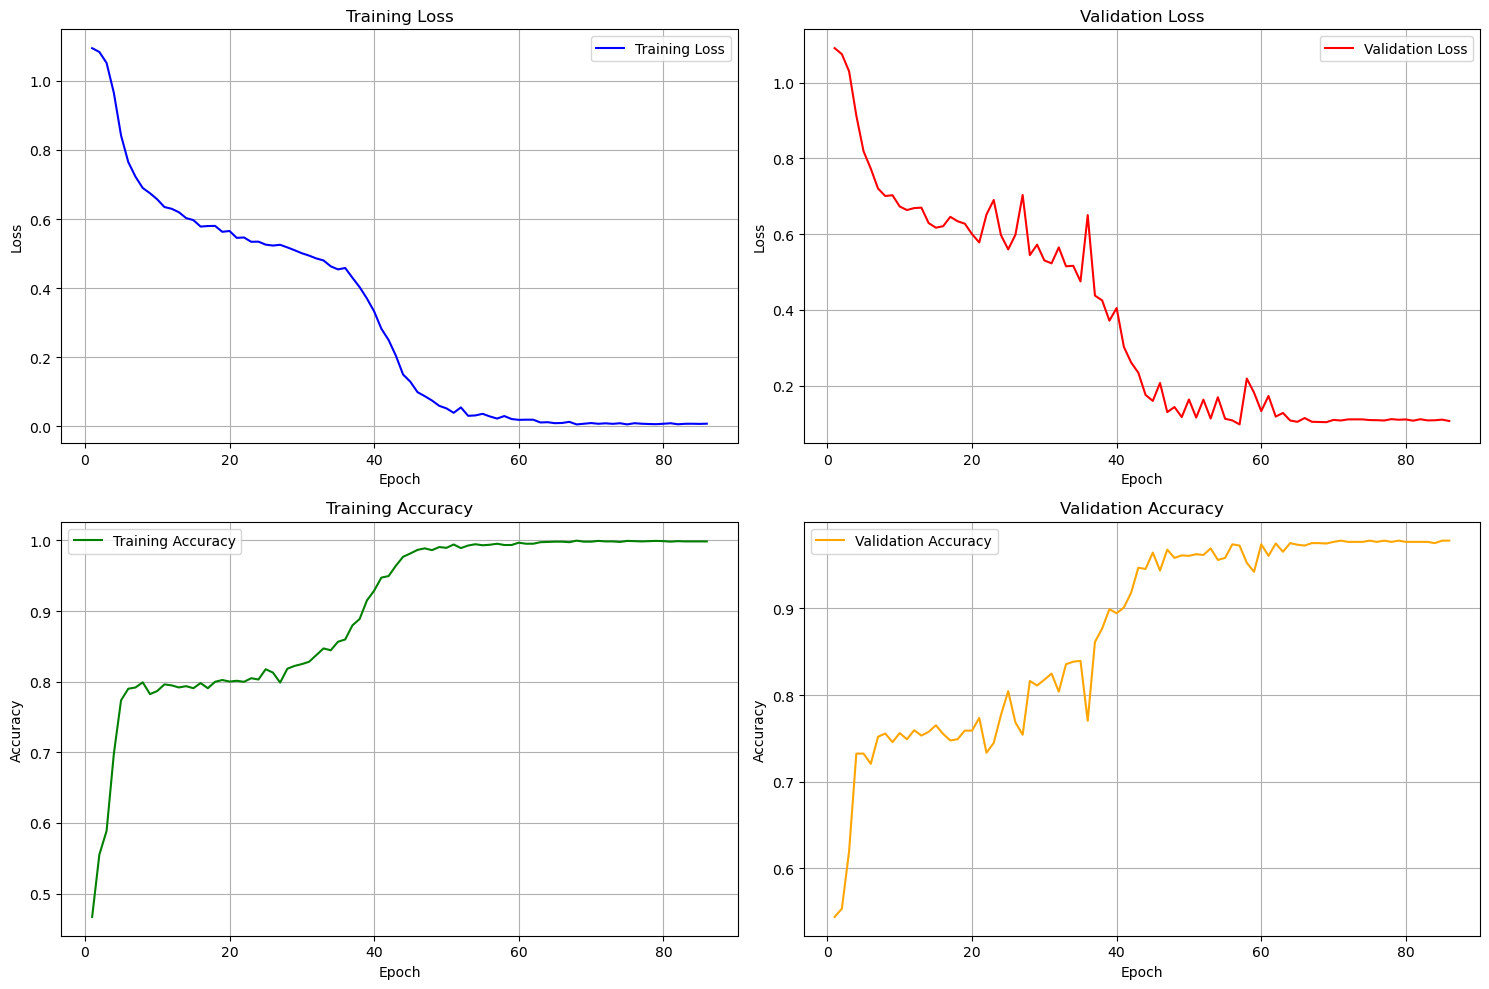

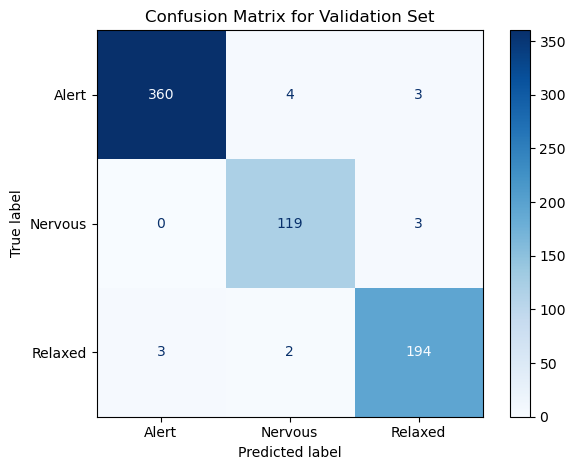

In [8]:
# 定义主函数
def main():
    # 检查 CUDA 是否可用，如果可用则使用 GPU，否则使用 CPU
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    # 打印正在使用的设备
    print(f"Using device: {device}")
    
    # 1. 加载全部数据 (从 dataset/train)
    print("Loading all data from ./dataset/train ...")
    # 这一步会读取所有 CSV 文件
    full_dataset = EEGDataset(root_folder="./dataset/train")

    # 检查总数据量
    if len(full_dataset) == 0:
        print("Dataset is empty. Please check folder paths.")
        return

    # 2. 自动切分验证集 (80% 训练, 20% 验证)
    train_size = int(0.8 * len(full_dataset))
    val_size = len(full_dataset) - train_size

    # 使用 random_split 切分
    # generator=torch.Generator().manual_seed(42) 确保每次切分结果一致
    train_dataset, val_dataset = torch.utils.data.random_split(
        full_dataset, 
        [train_size, val_size],
        generator=torch.Generator().manual_seed(42) 
    )

    # =============== 关键修正开始 ===============
    # Subset 对象默认没有 labels 和 data 属性，我们需要手动加上
    # 这样后续的代码（打印日志、计算权重）才能正常运行
    
    # 1. 挂载 Labels (用于计算 Class Weights)
    train_dataset.labels = full_dataset.labels[train_dataset.indices]
    val_dataset.labels = full_dataset.labels[val_dataset.indices]
    
    # 2. 挂载 Classes 和 Encoder (用于显示类别名称)
    train_dataset.classes = full_dataset.classes
    val_dataset.classes = full_dataset.classes
    train_dataset.label_encoder = full_dataset.label_encoder
    
    # 3. 挂载 Data (用于 Data Summary 打印日志 - 修复报错的核心)
    train_dataset.data = full_dataset.data[train_dataset.indices]
    val_dataset.data = full_dataset.data[val_dataset.indices]
    # =============== 关键修正结束 ===============
    
    print(f"Data split completed: {len(train_dataset)} training samples, {len(val_dataset)} validation samples.")

    # 3. 打印详细日志 (现在不会报错了，因为我们已经手动加上了 .data)
    print("===================== Data Summary =====================")
    
    # 创建类别映射字典
    class_mapping = dict(zip(full_dataset.label_encoder.classes_, full_dataset.label_encoder.transform(full_dataset.label_encoder.classes_)))
    print(f"Classes found and encoded: {class_mapping}")
    
    print("\n[Train Set]")
    print(f"  - Samples:    {len(train_dataset)}")
    print(f"  - Shape:      {train_dataset.data.shape}") # 之前报错的地方
    print(f"  - Labels:     {np.bincount(train_dataset.labels)}")
    print(f"  - Data Range: Min={train_dataset.data.min():.4f}, Max={train_dataset.data.max():.4f}")

    print("\n[Validation Set]")
    print(f"  - Samples:    {len(val_dataset)}")
    print(f"  - Shape:      {val_dataset.data.shape}")
    print(f"  - Labels:     {np.bincount(val_dataset.labels)}")
    print(f"  - Data Range: Min={val_dataset.data.min():.4f}, Max={val_dataset.data.max():.4f}")
    print("========================================================")

    # 4. 创建DataLoader
    train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True) 
    val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
    
    # 获取类别的总数
    num_classes = len(full_dataset.classes)
    
    # 实例化模型
    model = EEGBiFormer(num_classes=num_classes).to(device)
    
    # 开始训练
    train_model(model, train_loader, val_loader, device=device)

# 程序的入口点
# 检查当前脚本是否是作为主程序直接运行
if __name__ == "__main__":
    # 如果是，则调用 main() 函数
    main()